In [3]:
import pandas as pd
import numpy as np
import plotly
import plotly.express as px
import plotly.graph_objs as go
import plotly.io as pio
from plotly.offline import iplot
from sklearn.linear_model import LinearRegression as lr
import matplotlib.pyplot as plt
from ipywidgets import HBox, VBox

from datetime import datetime

from IPython.display import display

# Prerequisites (Ubuntu 18.04): 
# -nvm install any specific version of node
# -sudo apt-get libgtk2.0-0 libgconf-2-4
# -npm install -g electron@1.8.4 orca
# -edit path below to your specific node version
# -pip install jupyterlab ipywidgets
# -export NODE_OPTIONS=--max-old-space-size=4096
# -jupyter labextension install @jupyter-widgets/jupyterlab-manager --no-build
# -jupyter labextension install jupyterlab-plotly --no-build
# - jupyter labextension install plotlywidget@1.1.0 --no-build

plotly.io.orca.config.executable = '/home/tyler/.nvm/versions/node/v12.12.0/bin/orca'

In [1]:
df = pd.read_csv('data/curves_points.csv')

NameError: name 'pd' is not defined

In [3]:
monkeys = {
    'U': {'id': 1, 'color': 'blue'},
    'Y': {'id': 3, 'color': 'green'},
    'Z': {'id': 4, 'color': 'red'}
}

orange_colors = ['#ffc800', '#ff5800','#ff7f0e']
blue_colors = ['#5eade3','#1f77b4','#124669']

channels = {
    '1': {'id': 8, 'marker': 'circle-open'},
    '2': {'id': 7, 'marker': 'square-open'},
    '3': {'id': 22, 'marker': 'diamond-open'},
    '4': {'id': 12, 'marker': 'cross-open'},
    '1+2': {'id': 14, 'marker': 'triangle-up-open'},
    '2+1': {'id': 15, 'marker': 'triangle-up-open'},
    '2+3': {'id': 17, 'marker': 'triangle-down-open'},
    '3+4': {'id': 18, 'marker': 'triangle-left-open'},
    '4+1': {'id': 33, 'marker': 'triangle-left-open'},
    '1+2+3+4': {'id': 13, 'marker': 'star-open'},
}

charge_colors = {'U': ['#5eade3','', '#124669'], 'Y':['#ffc800', '','#ff7f0e']}

In [4]:
def filter_data(df, filters):
    for parameter, value in filters.items():
        if (parameter=='date_range'):
            df = df[df['days'] > value[0]]
            df = df[df['days'] < value[1]]
        elif (parameter=='discrimination'):
            delta_amp = df['comp_amp'] - df['ref_amp']
            delta_pw = df['comp_pw'] - df['ref_pw']
            mask = delta_amp 
            if (value == True):
                df = df[df['ref_amp'] != 0]
            else:
                df = df[df['ref_amp'] == 0]
        elif (parameter=='refamp_range'):
            df = df[df['ref_amp'] > value[0]]
            df = df[df['ref_amp'] < value[1]]
        elif (parameter=='charge_range'):
            df = df[df['q_ref'] > value[0]]
            df = df[df['q_ref'] < value[1]]
        elif (parameter=='chan_list'):
            df = df[df['ref_chans'].isin(value)]
        elif (parameter=='refamp_list'):
            df = df[df['ref_amp'].isin(value)]
        elif (parameter=='refpw_list'):
            df = df[df['ref_pw'].isin(value)]
        else:
            df = df[df[parameter] == value]
    return df

def remove_outliers(df, identifier, ids):
    for id in ids:
        df = df[df[identifier] != id]
    return df

In [5]:
df1 = df
for i, row in df1.iterrows():
    if row['varparamsID'] == 7:
        df_temp = df1[df1['idcurves'] == row['idcurves']]
        if len(df_temp.comp_amp.unique()) == 1:
            df1.at[i,'varparamsID'] = 3
        elif len(df_temp.comp_pw.unique()) == 1:
            df1.at[i,'varparamsID'] = 1
df = df1

KeyError: 'varparamsID'

remove outliers:

In [216]:
ids = [93, 163, 278, 328, 466, 518,557, 674, 713, 760, 761, 762, 766, 720, 655,
       718, 338, 1102, 904, 657, 889, 902, 903, 912, 913, 949, 950, 982, 985, 
       992, 1010, 1061, 1064, 1055, 1011, 1015, 1047, 1060, 1071, 1075, 1084, 
       1099, 1103, 1107, 1123,
      294,293,260,593,292,523,519,247,248,246,311,301]
    #delete & inspect last line,
df = remove_outliers(df,'idcurves',ids)

In [7]:
%%html
<style>
table {float:left}
</style>

# Results

### Total number of sessions:

In [8]:
print(df.sessionID.unique().size)

394


## Results Summary
Over 400 experimental sessions were performed, ranging from 20 to 628 days post-implantation.  Table 1 lists, for each monkey, the number of experimental sessions performed, the number of days since implantation on the first day of experiments, and the number of days since implantation on the last day of experiments.  Implants in Monkeys U and Y delivered detectable signals over the course of 1-2 years of chronic usage.  The implant in Monkey Z exhibited stable signals up to 4 months post implantation until lead failure near the site of the headcap ended experiments.

In [9]:
summary_data = []
for monkey in monkeys:
    df_monkey = df[df['subjectID']==monkeys[monkey]['id']]
    sessions = df_monkey['sessionID'].unique()
    days = df_monkey['days'].unique()
    summary_data.append([len(sessions), days.min(), days.max()])

summary_df = pd.DataFrame(summary_data, columns=["# of Sessions", "Start Day", "End Day"],
                         index=["Monkey U", "Monkey Y", "Monkey Z"])+
print(summary_df)

          # of Sessions  Start Day  End Day
Monkey U            221         21      628
Monkey Y            151         20      442
Monkey Z             22         89      127


## Table 1
| | # of Sessions | Start Day | End Day |
|----------|-----|----|-----|
| Monkey U | 221 | 21 | 628 |
| Monkey Y | 151 | 20 | 442 |
| Monkey Z | 22 | 89 | 127 | 

In [94]:
fig_template = go.layout.Template(
    layout=go.Layout(font={'family':'arial','size':12},
                    template="plotly_white",
                    xaxis={'ticks':'outside','rangemode':'tozero',
                           'title':{'font':{'size':20,'family':'arial'}}},
                    yaxis={'ticks':'outside', 'rangemode': 'tozero',
                           'title':{'font':{'size':20,'family':'arial'}}},
                     title_x=0,
                  legend={'x': .3, 'y': -.3, 'orientation':'h'},
)
)

#### define absolute threshold v time plot function

In [194]:
def thresh_fig(df,shade=[]):
    traces = []
    if shade:
        traces.append(go.Scatter(x=[105, 130],y=[1100, 1100], fill='tozeroy', fillcolor='whitesmoke', mode='none',showlegend=False))
    for i in monkeys:
        df1_monkey = df1[df1["subjectID"] == monkeys[i]['id']]
        for j in channels:
            df1_monkey_chan = df1_monkey[df1_monkey["ref_chans"] == channels[j]['id']]
            traces.append(
                go.Scatter(
                    x=df1_monkey_chan['days'],
                    y=(df1_monkey_chan['threshold']),
                    mode='markers',
                    marker={
                        'symbol': channels[j]["marker"],
                        'color': monkeys[i]['color'],
                        'size': 15,
                        'line': {'width': 0.5, 'color': 'white'}
                    },
                    name=i+j,
                    text=df1_monkey_chan['idcurves'],
                )
            )
    layout=go.Layout(
                    xaxis={
                           'showgrid':False,'showline':True},
                    yaxis={'showgrid':False,'showline':True,},
                    template=fig_template
    )
    
    
    return go.Figure(data=traces, layout=layout)

#### define difference threshold v time plot function

In [243]:
def thresh_fig_discrim(df,ref_var='ref_amp'):
    traces = []
    symbols = ['circle','circle-open','circle-cross-open','asterisk-open','square','square-open','square-cross-open']
    ref_amps = df[ref_var].unique()
    for j, ref_amp in enumerate(ref_amps):
        df1=df[df[ref_var]==ref_amp]
        x_np = df1['days'].to_numpy()
        y_np = df1['threshold'].to_numpy()
        x_np = x_np[~np.isnan(y_np)]
        y_np = y_np[~np.isnan(y_np)]
        x_np = x_np.reshape(-1, 1)
        if x_np.size != 0:
            model = lr().fit(x_np,y_np)
            print(model.coef_)
#             traces.append(
#                 go.Scatter(
#                     x = [x_np.min(), x_np.max()],
#                     y = model.predict(np.asarray([x_np.min(), x_np.max()]).reshape(-1,1)),
#                     mode='lines',
#     #                         line={
#     #         #                     'color': charge_colors[str(varparamID)]
#     #                         }
#                         )
#                     )
        traces.append(
            go.Scatter(
                x=df1[df1[ref_var]==ref_amp]['days'],
                y=df1[df1[ref_var]==ref_amp]['threshold'],
                mode='markers',
                opacity=.7,
                marker={
                    'symbol': symbols[j],
                    'size': 15,
                },
                name=str(ref_amp) + 'μs',
                text=df1['days'],
            )
        )
    layout = go.Layout(
        xaxis={'title': "Days from Implantation"},
        legend={'x': 0, 'y': -.3, 'orientation':'h', },
        hovermode='closest',
        template=fig_template,
        font={'family':'arial','size':12},
    )
    return go.Figure(data=traces, layout=layout)

#### define psychometric plot function

In [196]:
def psychometric_fig(df0,varparam='amp'):
    monkeys = {'1':'blue',
    '3': 'green',
    '4': 'red'}
    names = {'1':'Monkey U','3':'Monkey Y','4':'Monkey Z'}
    symbols = {'1':'circle-open', '3':'square-open','4':'diamond-open'}
    flag1=False; flag2=False; flag3=False
    if varparam=='amp':
        ref_var = 'ref_amp'
        comp_var = 'comp_amp'
    elif varparam=='pw':
        ref_var = 'ref_pw'
        comp_var = 'comp_pw'
    curvelist = df0["idcurves"].unique()
    fig = go.Figure()
    for curveID in curvelist:
        df = df0[df0["idcurves"] == curveID]
        a = df["threshold"].iloc[0]
        b = df["slope"].iloc[0]
        gamma = df["fittedFArate"].iloc[0]
        lambd = df["fittedLapseRate"].iloc[0]
        monkeyID = df['subjectID'].iloc[0]
        ref_val = df[ref_var].iloc[0]
        x = np.arange(int(df[comp_var].min()),int(df[comp_var].max()),.5) - ref_val
        y = (gamma + (1 - gamma - lambd)*(1/(1+np.exp(-1*(b)*(x-a)))))
        if curveID in [110,725,814]:
            showlegend=True
        else:
            showlegend=False
        fig.add_trace(
            go.Scatter(
                x=df[comp_var]-ref_val,
                y=df["HR"],
                hovertext=df['idcurves'],
                mode='markers',
                marker={
                    'size': 10,
                    'color':  monkeys[str(monkeyID)],
                    'symbol': symbols[str(monkeyID)],
#                     'line': {'width':2},
                },
                name=names[str(monkeyID)],
                showlegend=showlegend
            )
        )
        fig.add_trace(
            go.Scatter(
                x=x,
                y=y,
                line=dict(color= monkeys[str(monkeyID)], width=3),
                showlegend= False,
            )
        )
    fig.update_layout(
        xaxis={'title_text':"Stimulus Amplitude (μA)",
               'showgrid':False,'showline':True},
        yaxis={'title': "Hit Rate",'showgrid':False,'showline':True,},
        hovermode='closest',
        showlegend=True,
        template=fig_template,
        shapes=[
            go.layout.Shape(
                type="line",
                xref='paper',
                x0=0,
                x1=1,
                y0=.5,
                y1=.5,
                line=dict(
                    color="grey",
                    width=2,
                    dash="dash",
                ),
            ),
        ]
        
    )
    return fig

Figure 2 shows psychometric curves from each monkey for direct comparison during a 1-month period 90-120 days post-implantation. Monkey Z showed the lowest threshold values averaging 33 ± 4.5 μA (n=16).  During this same period, Monkey Y showed thresholds of 108 ± 18 μA (n=13) and Monkey U showed thresholds of 257 ± 18 μA (n=6). 

### Table 2

| Monkey | Channel | n  | 
|--------|---------|----|
| U      | 1       | 20 |
| U      | 2       | 52 |
| U      | 3       | 25 |
| U      | 4       | 26 |
| Y      | 1       | 10 |
| Y      | 2       | 33 |
| Y      | 3       | 25 |
| Y      | 4       | 22 |
| Z      | 2       | 19 |

## Figure 2B

In [202]:
filters = {'cs':0, 'discrimination':False, 'varparamsID':1}
df1 = filter_data(df, filters)
fig = thresh_fig(df1,shade=[105,130])

fig.update_traces(marker={'size':10,'symbol':'circle-open'})
traces_to_remove_from_legend=['U2','U3','U4','U1+2','U2+1','U2+3','U3+4','U4+1',
                             'Y2','Y3','Y4','Y1+2','Y2+1','Y3+4','Z2','Z3','Z4']
for trace in traces_to_remove_from_legend:
    fig.update_traces(showlegend=False,selector={'name':trace})
fig.update_traces(name='Monkey U', selector={'name':'U1'})
fig.update_traces(name='Monkey Y', selector={'name':'Y1'})
fig.update_traces(name='Monkey Z', selector={'name':'Z1'})
fig.update_traces(marker_symbol='square-open', selector={'marker_color':'green'})
fig.update_traces(marker_symbol='diamond-open', selector={'marker_color':'red'})
fig.update_layout(yaxis={'title': "Absolute Threshold (Amplitude - μA)"},
                  width=1000, 
                  title='A',
                  title_font_size=20,
                  )

fig.write_image("Nov_Images/fig2b.svg",width=800)
fig2b = go.FigureWidget(fig)

In [198]:
df1.groupby('subjectID').threshold.describe()

,count,mean,std,min,25%,50%,75%,max
subjectID,,,,,,,,
1,1154.0,338.910832,227.366429,81.0907,150.2640,273.6030,470.9385,1063.8200
3,800.0,121.663021,46.322051,50.8619,91.8760,108.7250,132.3580,333.3070
4,191.0,39.307587,13.222918,24.8225,30.1512,34.0347,39.9524,76.0728


## Figure 2A

In [201]:
fig = go.Figure()
filters = {'date_range': [105,130], 'ref_amp': 0, 'varparamsID': 1, 'comp_pw': 200}
df1 = filter_data(df, filters)
ids = [793, 795, 796, 797, 819, 821, 824, 801, 807, 813, 820]
df1 = remove_outliers(df1,'idcurves',ids)
df1 = df1[df1['comp_amp'] < 401]
fig = psychometric_fig(df1)
fig.update_layout(xaxis={'title': "Stimulus Amplitude (μA)"},
                  showlegend=True,
                  width=1000, 
                  title='B',
                  title_font_size=20,
                  )
#fig.write_image("figures_10_2_2019/Figure1.png")
fig.write_image("Nov_Images/fig2a.svg", width=800)
df1[['threshold','slope']].describe()
fig2a = go.FigureWidget(fig)

### Figure 2

In [200]:
figure1 = VBox([fig2a,fig2b])
figure1

    'data': [{'fill': 'tozeroy',
              'fillcolor': 'whitesmoke',
      …

### Table 2
#### Monkey Y (all data)
| Channel   | Threshold (mean)   | std  | n | 
|---|---|---|---|
| 1   | 80.3  | 13.2  |  10 |   
| 2   | 116.3  | 12.1  | 33  |   
| 3   | 154.3  | 43.6  | 25  |   
| 4   | 106.8  | 63.8  | 22  |   

##### JND plot function definition

In [220]:
def jnd_fig(df1, ref_var='ref_amp',subplot=[1,1]):
    traces = []
    x_np = df1[ref_var].to_numpy()
    y_np = df1['threshold'].to_numpy()
    x_np = x_np[~np.isnan(y_np)]
    y_np = y_np[~np.isnan(y_np)]
    x_np = x_np.reshape(-1, 1)
    if x_np.size != 0:
        model = lr(fit_intercept=False).fit(x_np,y_np)
        traces.append(
            go.Scatter(
                x = [x_np.min(), x_np.max()],
                y = model.predict(np.asarray([x_np.min(), x_np.max()]).reshape(-1,1)),
                mode='lines',
                showlegend=False
#                         line={
#         #                     'color': charge_colors[str(varparamID)]
#                         }
                    )
                )
    for j in channels:
        df1_chan = df1[df1["ref_chans"] == channels[j]['id']]
        if df1_chan.size > 0:
#             x_np = df1_chan[ref_var].to_numpy()
#             y_np = df1_chan['threshold'].to_numpy()
#             x_np = x_np[~np.isnan(y_np)]
#             y_np = y_np[~np.isnan(y_np)]
#             x_np = x_np.reshape(-1, 1)
#             if x_np.size != 0:
#                 model = lr(fit_intercept=False).fit(x_np,y_np)
#                 print(model.coef_)
#                 traces.append(
#                     go.Scatter(
#                         x = [x_np.min(), x_np.max()],
#                         y = model.predict(np.asarray([x_np.min(), x_np.max()]).reshape(-1,1)),
#                         mode='lines',
# #                         line={
# #         #                     'color': charge_colors[str(varparamID)]
# #                         }
#                     )
#                 )
                traces.append(
                    go.Scatter(
                        x=df1_chan[ref_var],
                        y=(df1_chan['threshold']),
                        mode='markers',
                        opacity=0.7,
                        marker={
                            'symbol': channels[j]["marker"],
                            'size': 10,
                            
                        },
                        text=df1_chan['idcurves'],
                        name=str(j)
                    )
                )
    layout = go.Layout(
        xaxis={'title': "Reference Stimulus",'title_text':"Absolute Threshold Amplitude (μA)",
                           'showgrid':False,'showline':True},
        yaxis={'title': "Difference Threshold",'showgrid':False,'showline':True,},
        hovermode='closest',
        template=fig_template
        
    )
    return go.Figure(data=traces, layout=layout)

| Monkey | Weber Fraction (Amp) | Weber Fraction (PW) | Weber Fraction (Charge) | 
|---|---|---|---|
| U | .19 | .19 |  |
| Y | 1.1

#### Figure 4a

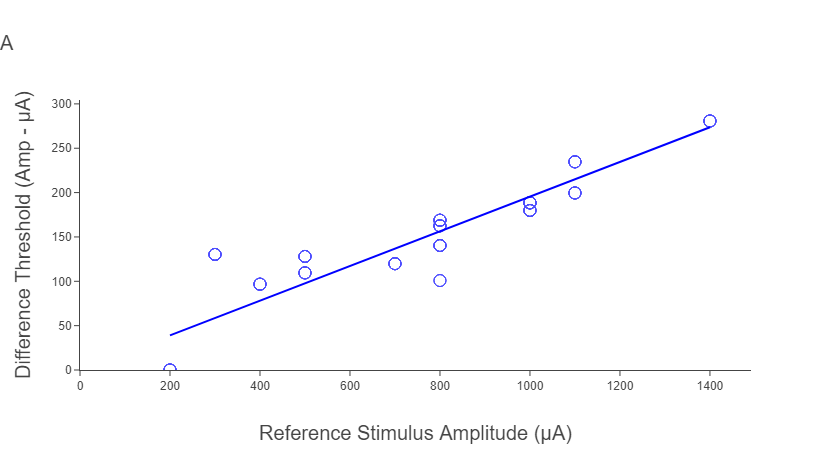

In [248]:
filters = {'discrimination':True, 'varparamsID': 1, 'comp_pw': 200, 'cs':False, 'subjectID': 1,
          'date_range':[250,700]}
df_U_amp = filter_data(df, filters)
# for curve in df_U_pw['idcurves'].unique():
#     points = df_U_pw[df_U_pw['idcurves'] == curve]
#     to_fit = points[['comp_amp','Hits','n']].to_numpy()
#     options = dict()
#     options['expType'] = 'YesNo'
#     options['sigmoidName'] = 'logistic'
#     res = ps.psignifit(to_fit, options)
#     df_U_pw.loc[df_U_pw['idcurves']==curve,'threshold'] = res['Fit'][0]
#     df_U_pw.loc[df_U_pw['idcurves']==curve,'slope'] = res['Fit'][1]
#     df_U_pw.loc[df_U_pw['idcurves']==curve,'fittedFArate'] = res['Fit'][2]
#     df_U_pw.loc[df_U_pw['idcurves']==curve,'fittedLapseRate'] = res['Fit'][3]

# df1 = pd.read_csv('df_U_pw.csv')
# df1.to_csv()
# df1 = filter_data(df1, {'date_range':[250,700]})
# df1 = df1.groupby(['idcurves']).mean()
# print(df1.groupby(['idcurves']).mean().groupby(['ref_chans']).head(100))
mask = df_U_amp['ref_chans'] ==8
df_U_amp_1 = df_U_amp[mask]
# df_U_amp.loc[mask, 'threshold'] = df_U_amp_not1['threshold'] - df_U_amp_not1['ref_amp']
fig = jnd_fig(df_U_amp_1)
fig.update_layout(yaxis={'rangemode': 'tozero'})
fig.update_layout(xaxis={'title': "Reference Stimulus Amplitude (μA)"},
                 yaxis={'title': "Difference Threshold (Amp - μA)"},
                 showlegend=False,
                 title='A',
                 title_font_size=20)
fig.update_traces(marker={'color':'blue','size':12},)
fig.write_image("Nov_Images/fig4a.svg")
iplot(fig)
fig4a = go.FigureWidget(fig)

## Figure 4c

In [266]:
filters = {'discrimination':True, 'varparamsID': 1, 'comp_pw': 200, 'cs':0, 'subjectID': 3, 'refamp_range': [0, 500],
          'chan_list':[7,8,22,12]}
df1 = filter_data(df, filters)
fig = jnd_fig(df1)
fig.update_traces(marker={'color':'green', 'size':12, 'symbol':'square-open'})
fig.update_layout(xaxis={'title': "Reference Amplitude (μA)"},
                  yaxis={'title': "Difference Threshold (Amp. - μA)"},
                  title='C',
                  title_font_size=20,
                  showlegend=False,
                 )
    
fig.write_image("Nov_Images/fig4c.svg")
fig4c = go.FigureWidget(fig)

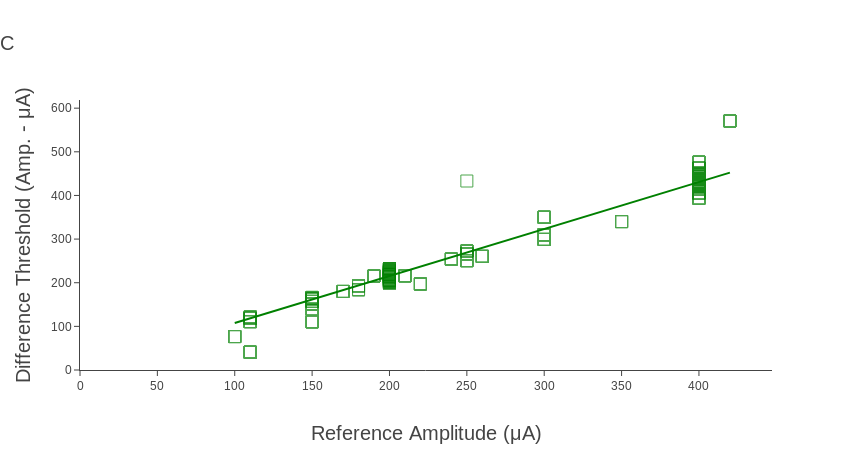

In [267]:
iplot(fig)

/home/tyler/.virtualenvs/thesis/lib/python3.7/site-packages/ipykernel_launcher.py:25: RuntimeWarning:

overflow encountered in exp



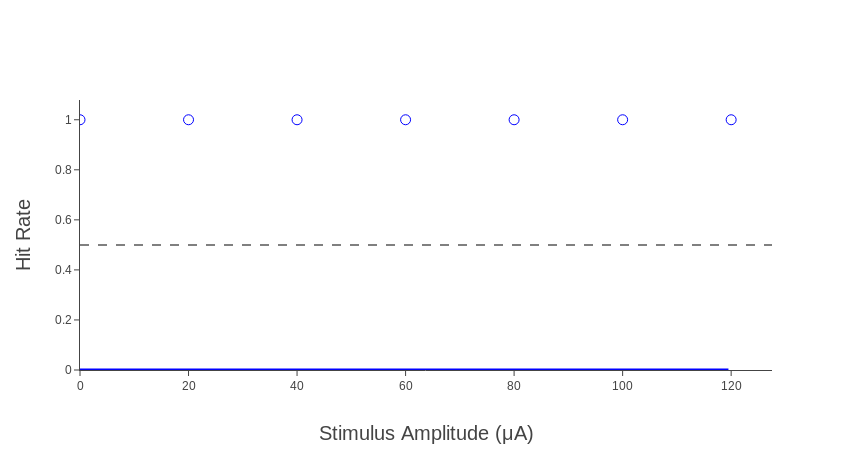

In [251]:
filter = {'idcurves':365}
df0 = filter_data(df,filter)
psychometric_fig(df0)

### Figure 3b

In [253]:
# #df_U_amp = pd.read_csv('df_U_amp.csv')
# df1 = df
# filters = {'discrimination':True, 'varparamsID': 1, 'comp_pw': 200, 'cs': False, 'subjectID':1,}
# df1 = filter_data(df1, filters)
# # df1.head()
# # df1.groupby(['idcurves']).mean().groupby(['ref_chans']).describe()
# fig = thresh_fig_discrim(df1)
# fig.update_layout(yaxis={'title': "Difference Threshold (μA) ", 'rangemode': 'tozero', 'showgrid':False,'ticks':'inside','showline':True,},
#                 xaxis={'title': "Days from Implantaion",
#                            'showgrid':False,'ticks':'inside','showline':True},
#                 legend={'x': 0, 'y': -.3, 'orientation':'h'},
#                 hovermode='closest',
#                 template='plotly_white',
#                  title='B',
#                  title_font_size=20,)
# fig.update_traces(marker={'color':'blue','size':10})
# fig.write_image("Nov_Images/fig4b.svg")
# iplot(fig)
# fig4b = go.FigureWidget(fig)

[-0.08869531]
[0.07463186]


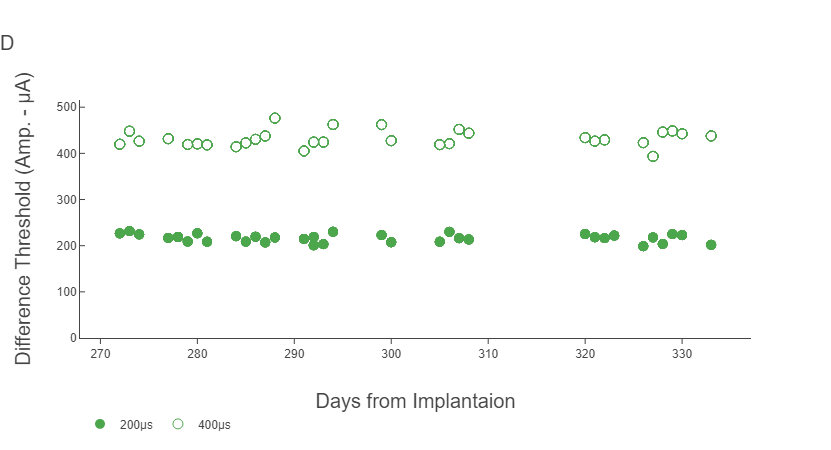

In [254]:
filters = {'discrimination':True, 'varparamsID': 1, 'comp_pw': 200, 'cs': False, 'subjectID':3, 'date_range': [250, 700],
          'refamp_range':[100, 500]}
df1 = filter_data(df, filters)
fig = thresh_fig_discrim(df1)
# fig.update_layout(
fig.update_layout(yaxis={'title': "Difference Threshold (Amp. - μA) ", 'showgrid':False,'ticks':'inside','showline':True,},
                  xaxis={'title': "Days from Implantaion",'rangemode':'normal',
                           'showgrid':False,'showline':True},
                    legend={'x': 0, 'y': -.3, 'orientation':'h'},
                hovermode='closest',
                  title='D',
                 title_font_size=20,
    )
fig.update_traces(marker={'color':'green','size':10})
fig.write_image("Nov_Images/fig4d.svg")
iplot(fig)
fig4d = go.FigureWidget(fig)

## Figure 5D

[100 150 200 250]
[1.29130728]
[5.07820245]
[0.35141801]
[-4.88403889]


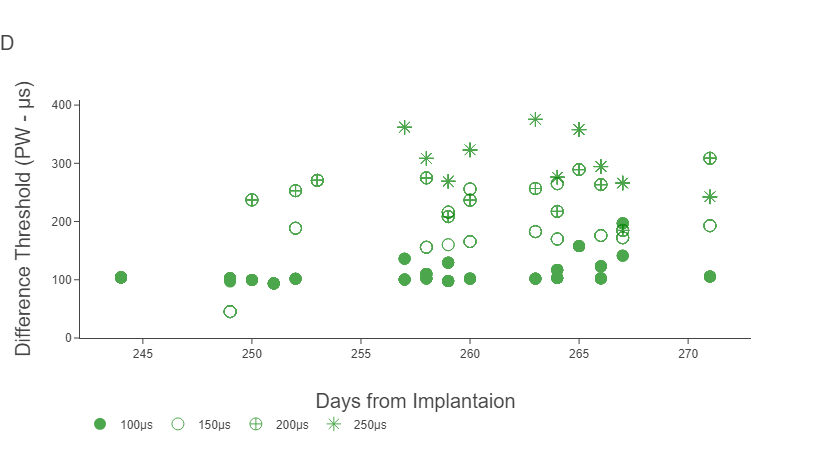

In [255]:
filters = {'discrimination':True, 'varparamsID': 3, 'cs': False, 'subjectID':3, 'refpw_list':[100,150,200,250]}
df1 = filter_data(df, filters)
print(df1['ref_pw'].unique())
fig = thresh_fig_discrim(df1, 'ref_pw')
# fig.update_layout(
fig.update_layout(yaxis={'title': "Difference Threshold (PW - μs) ", 'showgrid':False,'showline':True,},
                  xaxis={'title': "Days from Implantaion",
                           'showgrid':False,'showline':True,'rangemode':'normal'},
                    legend={'x': 0, 'y': -.3, 'orientation':'h'},
                hovermode='closest',
                template=fig_template,
                  title='D',
                 title_font_size=20,
    )
fig.update_traces(marker={'color':'green','size':12})
fig.write_image("Nov_Images/fig5d.svg")
iplot(fig)
fig5d = go.FigureWidget(fig)

## Figure 5b

[-1.38265163]
[-0.7512963]
[-0.92700709]
[-2.84022335]


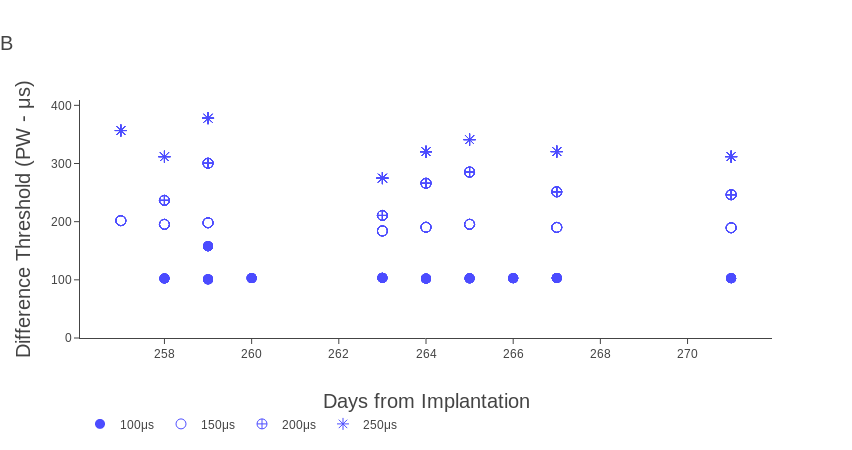

In [256]:
filters = {'discrimination':True, 'varparamsID': 3, 'comp_amp': 400, 'cs': False, 'subjectID':1, 'date_range':[255, 300],'refpw_list':[100,150,200,250]}
df1 = filter_data(df, filters)
df1 = df1[df1['ref_chans'] != channels['1']['id']]
df1 = df1.sort_values('ref_pw')
fig = thresh_fig_discrim(df1,'ref_pw')
fig.update_layout(yaxis={'title': "Difference Threshold (PW - μs)", 'showgrid':False,'showline':True,},
                xaxis={'title': "Days from Implantation", 'rangemode':'normal',
                           'showgrid':False,'showline':True},
                legend={'x': 0, 'y': -.3, 'orientation':'h'},
                hovermode='closest',
                 title='B',
                 title_font_size=20,)
fig.update_traces(marker={'color':'blue','size':10})
fig.write_image("Nov_Images/fig5b.svg")
iplot(fig)
fig5b = go.FigureWidget(fig)

(excluding channel 1)

### Pulse Width/Charge

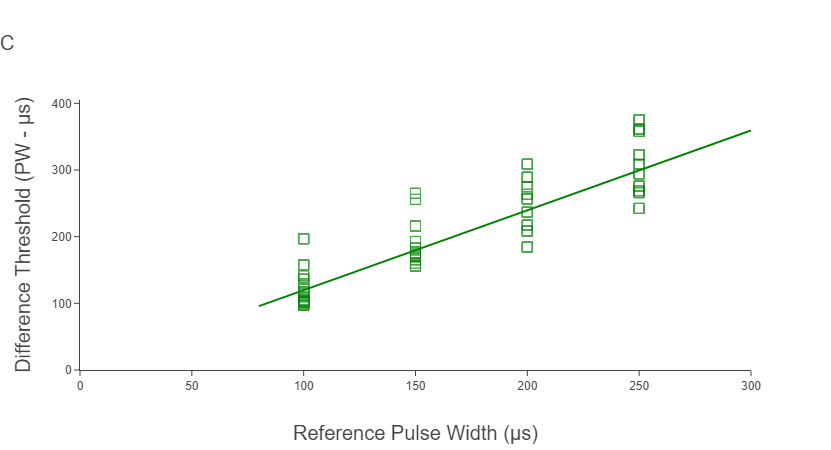

In [257]:
filters = {'discrimination':True, 'varparamsID': 3, 'cs': False, 'subjectID':3 }
df1 = filter_data(df, filters)
df1.head()
fig = jnd_fig(df1,'ref_pw')
fig.update_layout(yaxis={'title': "Difference Threshold (PW - μs)", 'rangemode': 'tozero'},
                 xaxis={'title': "Reference Pulse Width (μs)"},
                 showlegend=False,
                 title='C',
                 title_font_size=20)
fig.update_traces(marker={'color':'green','size':10,'symbol':'square-open'})
fig.write_image("Nov_Images/fig5c.svg")
iplot(fig)
fig5c = go.FigureWidget(fig)

## Figure 5a

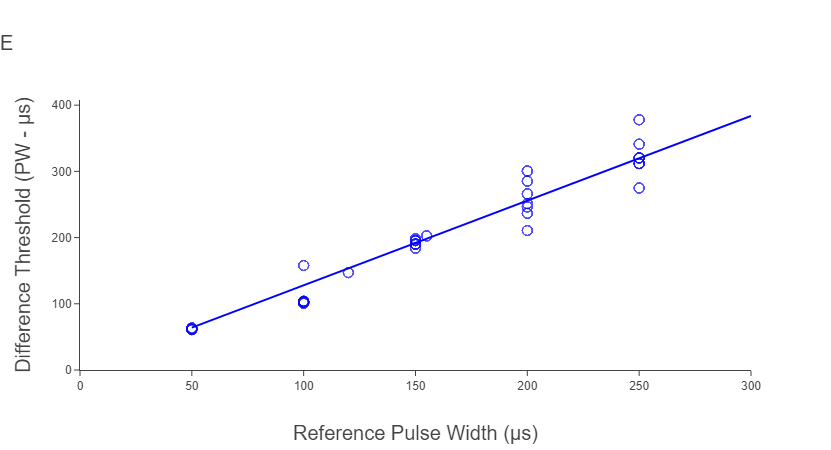

In [261]:
filters = {'discrimination':True, 'varparamsID': 3, 'cs': False, 'subjectID':1, 'comp_amp':400,
          }
df_U_pw = filter_data(df, filters)

# for curve in df1['idcurves'].unique():
#     points = df_U_pw[df_U_pw['idcurves'] == curve]
#     points['comp_pw'] = points['comp_pw']-points['ref_pw']
#     to_fit = points[['comp_pw','Hits','n']].to_numpy()
#     options = dict()
#     options['expType'] = 'YesNo'
#     options['sigmoidName'] = 'logistic'
#     res = ps.psignifit(to_fit, options)
#     df_U_pw.loc[df_U_pw['idcurves']==curve,'threshold'] = res['Fit'][0]
#     df_U_pw.loc[df_U_pw['idcurves']==curve,'slope'] = res['Fit'][1]
#     df_U_pw.loc[df_U_pw['idcurves']==curve,'fittedFArate'] = res['Fit'][2]
#     df_U_pw.loc[df_U_pw['idcurves']==curve,'fittedLapseRate'] = res['Fit'][3]
#     print(res['Fit'])

fig = jnd_fig(df_U_pw,'ref_pw')
fig.update_layout(yaxis={'title': "Difference Threshold (PW - μs)",'rangemode':'tozero'},
                 xaxis={'title': "Reference Pulse Width (μs)"},
                legend={'x': 0, 'y': -.3, 'orientation':'h'},
                 title='E',
                 title_font_size=20,
                 showlegend=False)
fig.update_traces(marker={'color':'blue', 'symbol':'circle-open'})
fig.write_image("Nov_Images/fig5a.svg")
iplot(fig)
fig5a = go.FigureWidget(fig)

In [263]:
figure4 = VBox([
    HBox([fig4a, go.FigureWidget(go.Figure())]), 
    HBox([fig4c, fig4d])
])
figure5 = VBox([
    HBox([fig5a, fig5b]),
    HBox([fig5c, fig5d])
])

In [264]:
figure4

    'data': [{'marker': {'color': 'blue', 'size': 12},
          …

In [265]:
figure5

    'data': [{'marker': {'color': 'blue', 'symbol': 'circle-open'…

In [268]:
def jnd_fig_q(df):
    traces = []
    monkeys = {'U':1,'Y':3}
    for monkey in ['U','Y']:
        df1 = df[df['subjectID'] == monkeys[monkey]]
        for varparamID in [1,3]:
            if varparamID==1:
                varname='Amp'
            elif varparamID==3:
                varname='PW'
            df1_type = df1[df1["varparamsID"] == varparamID]
            x_np = df1_type['q_ref'].to_numpy()
            y_np = df1_type['q_thresh'].to_numpy()
            x_np = x_np[~np.isnan(y_np)]
            y_np = y_np[~np.isnan(y_np)]
            x_np = x_np.reshape(-1, 1)
            
            if x_np.size != 0:
                model = lr(fit_intercept=False).fit(x_np,y_np)
                print(model.coef_)
                traces.append(
                    go.Scatter(
                        x = [x_np.min(), x_np.max()],
                        y = model.predict(np.asarray([x_np.min(), x_np.max()]).reshape(-1,1)),
                        mode='lines',
                        line={
                            'dash':'dash',
                            'color': charge_colors[monkey][varparamID-1]
                        }
                    )
                )
            for j in channels:
                df1_type_chan = df1_type[df1_type["ref_chans"] == channels[j]['id']]
                traces.append(
                    go.Scatter(
                        x=df1_type_chan['q_ref'],
                        y=(df1_type_chan['q_thresh']),
                        mode='markers',
                        opacity=0.7,
                        marker={
                            'symbol': channels[j]["marker"],
                            'color': charge_colors[monkey][varparamID-1],
                            'size': 15,
                            'line': {'width': 0.5, 'color': 'white'}
                        },
                        text=df1_type_chan['days'],
                        name=monkey + varname,
                    )
                )
    
    layout = go.Layout(
        xaxis={'title': "Reference Stimulus"},
        yaxis={'title': "Relative Threshold"},
        legend={'x': 0, 'y': -.3, 'orientation':'h'},
        hovermode='closest'
    )
    return go.Figure(data=traces, layout=layout)

In [ ]:
#refit curve
curve = 1064
df1 = df
points = df1[df1['idcurves'] == curve]
points['comp_amp'] = points['comp_amp']-points['ref_amp']
to_fit = points[['comp_amp','Hits','n']].to_numpy()
options = dict()
options['expType'] = 'YesNo'
options['sigmoidName'] = 'logistic'
res = ps.psignifit(to_fit, options)
df.loc[df['idcurves']==curve,'threshold'] = res['Fit'][0]
df.loc[df['idcurves']==curve,'slope'] = res['Fit'][1]
df.loc[df['idcurves']==curve,'fittedFArate'] = res['Fit'][2]
df.loc[df['idcurves']==curve,'fittedLapseRate'] = res['Fit'][3]
print(res['Fit'])
psychometric_fig(df[df['idcurves']==curve])

In [ ]:
psychometric_fig(df[df['idcurves']==1040],varparam='amp')

In [ ]:
curve = 294
df.loc[df['idcurves']==curve,'fittedLapseRate'] = 0.05
psychometric_fig(df[df['idcurves']==curve],varparam='pw')

[0.41265678]
[1.24481833]
[0.95252623]
[1.23237597]


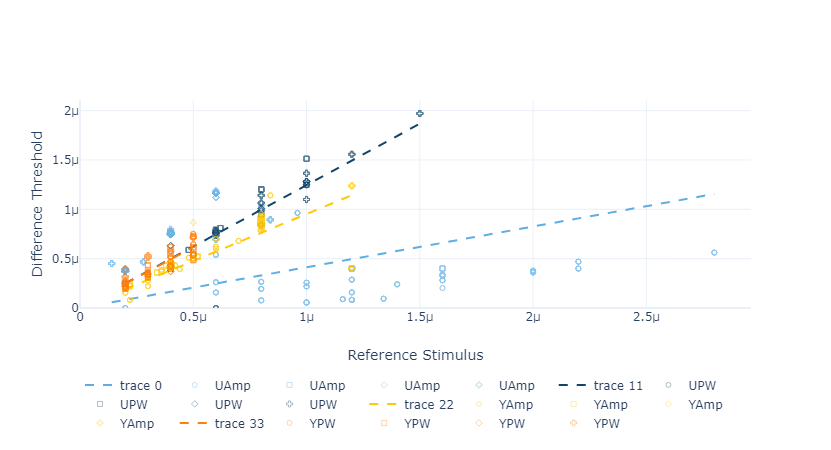

In [269]:
df1 = df
for i, row in df1.iterrows():
    if row['varparamsID'] == 1:
        df1.at[i, 'q_thresh'] = row['threshold'] * row['comp_pw'] * 10e-12
    elif row['varparamsID'] == 3:
        df1.at[i,'q_thresh'] = row['threshold'] * row['comp_amp'] * 10e-12
    df1.at[i, 'q_ref'] = row['ref_amp'] * row['ref_pw'] * 10e-12

filters = {'discrimination':True, 'cs': False, 'charge_range': [0, 100000], 'chan_list': [7,8,22,12]}
df1 = filter_data(df1, filters)
fig = jnd_fig_q(df1)
fig.update_traces(marker={'size':5})
fig.update_layout(yaxis={'title': "Difference Threshold", 'rangemode': 'tozero'},
                 xaxis={'rangemode': 'tozero'},
                 template='plotly_white')
iplot(fig)

In [ ]:
df_U_pw.to_csv('df_U_pw')
curve = 523
df1=df
# df1.size
df1 = filter_data(df1,{'idcurves': curve})
df_U_pw = df1
points = df_U_pw[df_U_pw['idcurves'] == curve]
points['comp_pw'] = points['comp_pw']-100
to_fit = points[['comp_pw','Hits','n']].to_numpy()
print(to_fit)
options = dict()
options['expType'] = 'YesNo'
options['sigmoidName'] = 'logistic'
res = ps.psignifit(to_fit, options)
df_U_pw.loc[df_U_pw['idcurves']==curve,'threshold'] = res['Fit'][0]
df_U_pw.loc[df_U_pw['idcurves']==curve,'slope'] = res['Fit'][1]
df_U_pw.loc[df_U_pw['idcurves']==curve,'fittedFArate'] = res['Fit'][2]
df_U_pw.loc[df_U_pw['idcurves']==curve,'fittedLapseRate'] = res['Fit'][3]
print(res['Fit'])


iplot(psychometric_fig(df1,'#1f77b4','pw'))

Note:  PW had different weber fractions for individual channels; could correspond to different amplitude thresholds

In [ ]:
Note: manually changed 291, 519,

In [ ]:
df.to_csv('cleaned_data_10_3.csv')